# Тема 3: «Решение задачи Коши для обыкновенного дифференциального уравнения первого порядка»

### Вариант 2

  Решить задачу Коши значит найти функцию y(x), которая:                                                                                            
  1. Удовлетворяет уравнению y' = f(x, y) на всём отрезке [x₀, b]
  2. Проходит через начальную точку y(x₀) = y₀ 

  Так как правая часть f(x, y) = eˣ - e⁻ˣ не зависит от y, это по сути задача численного интегрирования. Точное решение:

  ∫(eˣ - e⁻ˣ)dx = eˣ + e⁻ˣ + C <br/>
  y(0) = 1 + 1 + C = 0  →  C = -2 <br/>
  y(x) = eˣ + e⁻ˣ - 2

  Значение в правом конце: y(1) = e + 1/e - 2 ≈ 1.08616

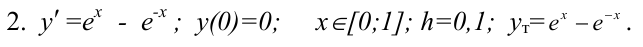

In [1]:
import math                      # нужен для exp()
import matplotlib.pyplot as plt   # нужен для графиков

# y' = f(x, y) = e^x - e^{-x}
# уравнение не зависит от y 
def f(x, y):
    return math.exp(x) - math.exp(-x)

# АНАЛИТИЧЕСКОЕ РЕШЕНИЕ
# Получаем интегрированием правой части:
# ∫(e^x - e^{-x}) dx = e^x + e^{-x} + C
# Из начального условия y(0) = 0:
# 0 = e^0 + e^0 + C = 1 + 1 + C  =>  C = -2
# Итого: y(x) = e^x + e^{-x} - 2
def y_exact(x):
    return math.exp(x) + math.exp(-x) - 2

# ПАРАМЕТРЫ ЗАДАЧИ (из условия варианта 2)
x0, y0 = 0.0, 0.0       # начальная точка и начальное значение: y(0) = 0
b       = 1.0           # правый конец отрезка
h0      = 0.1           # начальный шаг сетки (дан в условии)
eps     = 1e-4          # требуемая точность вычислений

print(f"Задача: y' = e^x - e^(-x),  y({x0}) = {y0},  x ∈ [{x0}, {b}]")
print(f"Начальный шаг h = {h0},  точность eps = {eps}")
print(f"Точное решение y(x) = e^x + e^(-x) - 2")
print(f"Проверка: y(0) = {y_exact(0)},  y(1) = {y_exact(1):.8f}")

Задача: y' = e^x - e^(-x),  y(0.0) = 0.0,  x ∈ [0.0, 1.0]
Начальный шаг h = 0.1,  точность eps = 0.0001
Точное решение y(x) = e^x + e^(-x) - 2
Проверка: y(0) = 0.0,  y(1) = 1.08616127


### 1. Найдите решение задачи Коши для ОДУ первого порядка с точностью eps тремя численными методами:

Модифицированный метод Эйлера

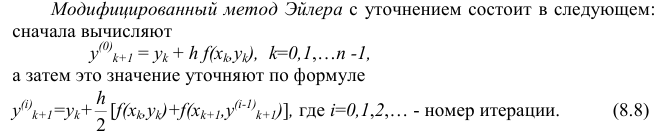

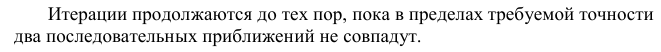

Обычный метод Эйлера (y_{n+1} = y_n + h·f_n) использует наклон только в левой точке отрезка [xₙ, xₙ₊₁]. Модифицированный берёт среднее наклонов на обоих концах.
https://youtu.be/dNr56t3MtoI?si=EksAOrobRWe7u2HY

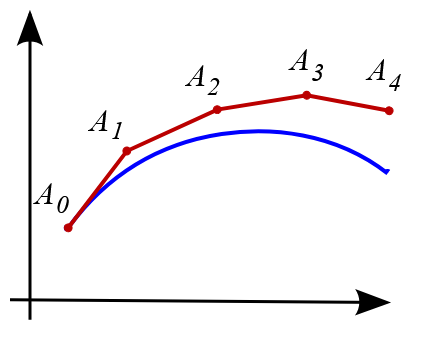

In [2]:
# Порядок точности: p = 2
#
# Модифицированный метод Эйлера — сначала делает грубый шаг (ПРЕДИКТОР),
# а потом итеративно уточняет результат (КОРРЕКТОР),
# пока два соседних приближения не совпадут с точностью eps_inner.

def modified_euler(f, x0, y0, b, h, eps_inner=1e-12):

    x, y   = x0, y0
    xs, ys = [x], [y]
    total_inner = 0        # счётчик итераций корректора (по всем шагам)

    while x + 1e-10 < b:

        h_cur = min(h, b - x)
        # Последний шаг может быть короче h, если до b осталось меньше h.

        f_k = f(x, y)
        # Запоминаем значение правой части в текущей точке.
        # Оно нужно и для предиктора, и для каждого шага корректора.

        # ПРЕДИКТОР (формула обычного Эйлера)
        # y^(0)_{k+1} = y_k + h * f(x_k, y_k)
        y_cur = y + h_cur * f_k

        # КОРРЕКТОР (итеративное уточнение)
        # y^(i)_{k+1} = y_k + h/2 * [f(x_k, y_k) + f(x_{k+1}, y^(i-1)_{k+1})]
        # Повторяем, пока результат не перестанет меняться.
        inner = 0
        while True:
            y_prev = y_cur                                           # запомнили предыдущее приближение
            y_cur  = y + h_cur / 2 * (f_k + f(x + h_cur, y_prev))  # применили корректор
            inner += 1
            if abs(y_cur - y_prev) < eps_inner:
                break

        total_inner += inner   # накапливаем общий счётчик

        y  = y_cur
        x  = round(x + h_cur, 12)   # round убирает хвосты вроде 0.30000000000000004
        xs.append(x)
        ys.append(y)

    return xs, ys, total_inner


xs_me, ys_me, inner_total_me = modified_euler(f, x0, y0, b, h0, eps_inner=eps)

print(f"{'x':>6} | {'y_Эйлер':>14} | {'y_точное':>14} | {'погрешность':>12}")
print("-" * 55)
for xv, yv in zip(xs_me, ys_me):
    print(f"{xv:>6.3f} | {yv:>14.7f} | {y_exact(xv):>14.7f} | {abs(yv-y_exact(xv)):>12.2e}")

     x |        y_Эйлер |       y_точное |  погрешность
-------------------------------------------------------
 0.000 |      0.0000000 |      0.0000000 |     0.00e+00
 0.100 |      0.0100167 |      0.0100083 |     8.34e-06
 0.200 |      0.0401670 |      0.0401335 |     3.34e-05
 0.300 |      0.0907526 |      0.0906770 |     7.56e-05
 0.400 |      0.1622798 |      0.1621447 |     1.35e-04
 0.500 |      0.2554646 |      0.2552519 |     2.13e-04
 0.600 |      0.3712395 |      0.3709304 |     3.09e-04
 0.700 |      0.5107632 |      0.5103380 |     4.25e-04
 0.800 |      0.6754322 |      0.6748699 |     5.62e-04
 0.900 |      0.8668945 |      0.8661728 |     7.22e-04
 1.000 |      1.0870663 |      1.0861613 |     9.05e-04


Метод Рунге-Кутта (второго или четвертого порядка точности)

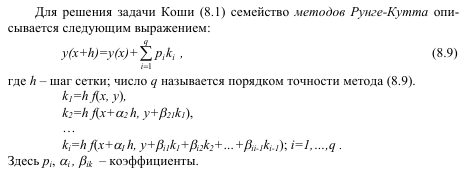

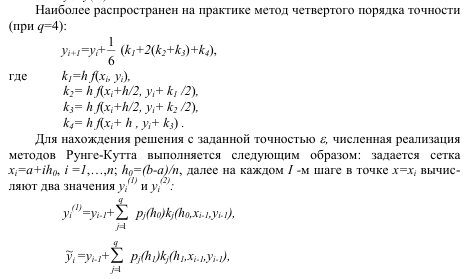

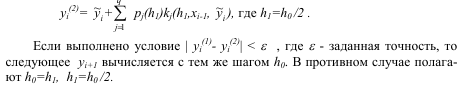

In [3]:
def rk4_step(x, y, h):
    k1 = h * f(x,         y         )
    k2 = h * f(x + h/2,   y + k1/2  )
    k3 = h * f(x + h/2,   y + k2/2  )
    k4 = h * f(x + h,     y + k3    )
    return y + (k1 + 2*k2 + 2*k3 + k4) / 6

xs_rk4 = [x0]
ys_rk4 = [y0]

x, y = x0, y0
h = h0

print(f"{'x':>6} | {'y_RK4':>14} | {'y_точное':>14} | {'погрешность':>12} | {'h':>8}")
print("-" * 65)
print(f"{x:>6.3f} | {y:>14.7f} | {y_exact(x):>14.7f} | {'—':>12} | {h:>8.5f}")

while x < b:
    if x + h > b:
        h = b - x

    y1     = rk4_step(x,       y,      h)
    y2_mid = rk4_step(x,       y,      h/2)
    y2     = rk4_step(x + h/2, y2_mid, h/2)

    if abs(y1 - y2) < eps:
        x = round(x + h, 10)
        y = y2
        xs_rk4.append(x)
        ys_rk4.append(y)
        err = abs(y - y_exact(x))
        print(f"{x:>6.3f} | {y:>14.7f} | {y_exact(x):>14.7f} | {err:>12.2e} | {h:>8.5f}")
    else:
        h = h / 2
        print(f"  → шаг уменьшен до h = {h:.5f}")

h_rk4 = h

     x |          y_RK4 |       y_точное |  погрешность |        h
-----------------------------------------------------------------
 0.000 |      0.0000000 |      0.0000000 |            — |  0.10000
 0.100 |      0.0100083 |      0.0100083 |     2.17e-11 |  0.10000
 0.200 |      0.0401335 |      0.0401335 |     8.71e-11 |  0.10000
 0.300 |      0.0906770 |      0.0906770 |     1.97e-10 |  0.10000
 0.400 |      0.1621447 |      0.1621447 |     3.52e-10 |  0.10000
 0.500 |      0.2552519 |      0.2552519 |     5.54e-10 |  0.10000
 0.600 |      0.3709304 |      0.3709304 |     8.05e-10 |  0.10000
 0.700 |      0.5103380 |      0.5103380 |     1.11e-09 |  0.10000
 0.800 |      0.6748699 |      0.6748699 |     1.46e-09 |  0.10000
 0.900 |      0.8661728 |      0.8661728 |     1.88e-09 |  0.10000
 1.000 |      1.0861613 |      1.0861613 |     2.36e-09 |  0.10000


Многошаговый метод (метод Адамса или метод Милна)

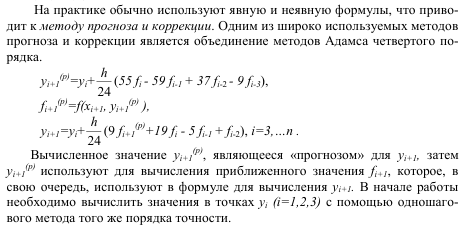

In [4]:
n = int((b - x0) / h0)  # = 10

# Шаг 1: стартовые значения y0..y3 через РК-4
xs_ad = [x0 + i * h0 for i in range(n + 1)]
ys_ad = [0.0] * (n + 1)
ys_ad[0] = y0
for i in range(3):
    ys_ad[i+1] = rk4_step(xs_ad[i], ys_ad[i], h0)

# Заполняем историю значений f
fs = [f(xs_ad[i], ys_ad[i]) for i in range(4)]  # f0, f1, f2, f3

print(f"{'i':>3} | {'x':>6} | {'y_Adams':>14} | {'y_точное':>14} | {'погрешность':>12} | {'метод':>8}")
print("-" * 70)
for i in range(4):
    tag = 'РК-4' if i > 0 else 'нач.усл.'
    print(f"{i:>3} | {xs_ad[i]:>6.2f} | {ys_ad[i]:>14.7f} | {y_exact(xs_ad[i]):>14.7f} | {abs(ys_ad[i]-y_exact(xs_ad[i])):>12.2e} | {tag:>8}")

# Шаг 2: метод Адамса для i = 3 .. n-1
for i in range(3, n):
    fi   = fs[3]
    fi_1 = fs[2]
    fi_2 = fs[1]
    fi_3 = fs[0]

    # Прогноз
    y_pred = ys_ad[i] + (h0/24) * (55*fi - 59*fi_1 + 37*fi_2 - 9*fi_3)

    # f в прогнозной точке
    f_pred = f(xs_ad[i+1], y_pred)

    # Коррекция
    ys_ad[i+1] = ys_ad[i] + (h0/24) * (9*f_pred + 19*fi - 5*fi_1 + fi_2)

    # Сдвигаем историю влево
    fs = [fs[1], fs[2], fs[3], f(xs_ad[i+1], ys_ad[i+1])]

    err = abs(ys_ad[i+1] - y_exact(xs_ad[i+1]))
    print(f"{i+1:>3} | {xs_ad[i+1]:>6.2f} | {ys_ad[i+1]:>14.7f} | {y_exact(xs_ad[i+1]):>14.7f} | {err:>12.2e} | {'Адамс':>8}")

h_ad = h0

  i |      x |        y_Adams |       y_точное |  погрешность |    метод
----------------------------------------------------------------------
  0 |   0.00 |      0.0000000 |      0.0000000 |     0.00e+00 | нач.усл.
  1 |   0.10 |      0.0100083 |      0.0100083 |     3.47e-10 |     РК-4
  2 |   0.20 |      0.0401335 |      0.0401335 |     1.39e-09 |     РК-4
  3 |   0.30 |      0.0906770 |      0.0906770 |     3.15e-09 |     РК-4
  4 |   0.40 |      0.1621449 |      0.1621447 |     1.48e-07 |    Адамс
  5 |   0.50 |      0.2552523 |      0.2552519 |     3.49e-07 |    Адамс
  6 |   0.60 |      0.3709310 |      0.3709304 |     6.07e-07 |    Адамс
  7 |   0.70 |      0.5103389 |      0.5103380 |     9.25e-07 |    Адамс
  8 |   0.80 |      0.6748712 |      0.6748699 |     1.31e-06 |    Адамс
  9 |   0.90 |      0.8661745 |      0.8661728 |     1.76e-06 |    Адамс
 10 |   1.00 |      1.0861635 |      1.0861613 |     2.28e-06 |    Адамс


### 2. Выполните проверку корректности полученных результатов, сравнив их с точным решением.

    x |     y_точное |      y_Эйлер |        y_РК4 |      y_Адамс |  |Δ|_Эйлер |    |Δ|_РК4 |  |Δ|_Адамс
---------------------------------------------------------------------------------------------------------
 0.00 |   0.00000000 |   0.00000000 |   0.00000000 |   0.00000000 |   0.00e+00 |   0.00e+00 |   0.00e+00
 0.10 |   0.01000834 |   0.01001668 |   0.01000834 |   0.01000834 |   8.34e-06 |   2.17e-11 |   3.47e-10
 0.20 |   0.04013351 |   0.04016695 |   0.04013351 |   0.04013351 |   3.34e-05 |   8.71e-11 |   1.39e-09
 0.30 |   0.09067703 |   0.09075258 |   0.09067703 |   0.09067703 |   7.56e-05 |   1.97e-10 |   3.15e-09
 0.40 |   0.16214474 |   0.16227984 |   0.16214474 |   0.16214489 |   1.35e-04 |   3.52e-10 |   1.48e-07
 0.50 |   0.25525193 |   0.25546460 |   0.25525193 |   0.25525228 |   2.13e-04 |   5.54e-10 |   3.49e-07
 0.60 |   0.37093044 |   0.37123949 |   0.37093044 |   0.37093104 |   3.09e-04 |   8.05e-10 |   6.07e-07
 0.70 |   0.51033801 |   0.51076322 |   0.51033801 |  

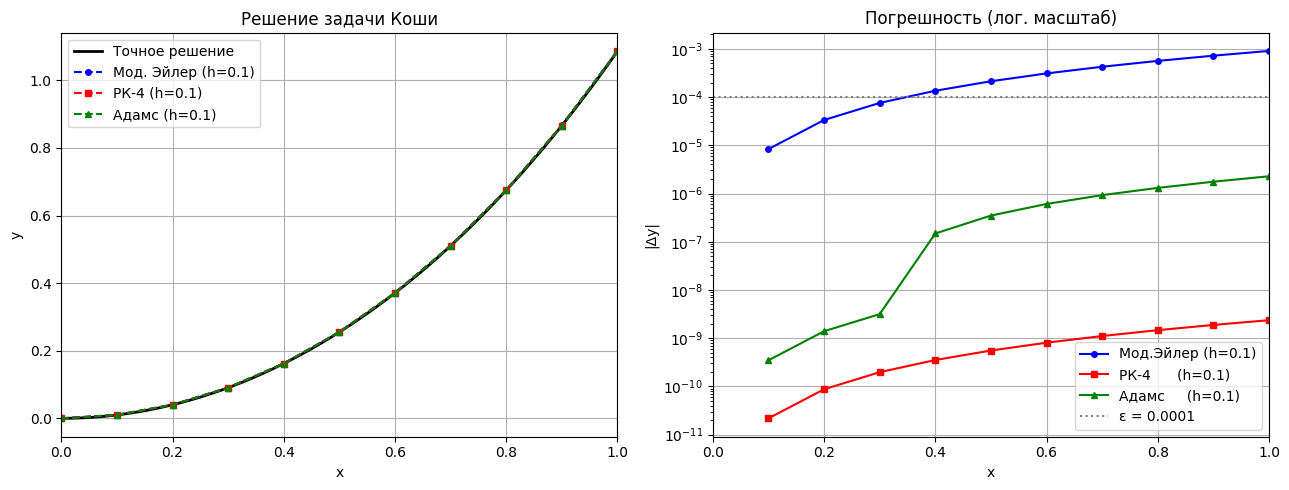

In [ ]:
def interp(xs, ys, xq):
    for i, xv in enumerate(xs):
        if abs(xv - xq) < 1e-9:
            return ys[i]
    for i in range(len(xs) - 1):
        if xs[i] <= xq <= xs[i+1]:
            t = (xq - xs[i]) / (xs[i+1] - xs[i])
            return ys[i] + t * (ys[i+1] - ys[i])
    return float('nan')

x_check = [round(x0 + i * h0, 10) for i in range(round((b - x0) / h0) + 1)]

print(f"{'x':>5} | {'y_точное':>12} | {'y_Эйлер':>12} | {'y_РК4':>12} | {'y_Адамс':>12} | {'|Δ|_Эйлер':>10} | {'|Δ|_РК4':>10} | {'|Δ|_Адамс':>10}")
print("-" * 105)
for xv in x_check:
    yt  = y_exact(xv)
    yme = interp(xs_me,  ys_me,  xv)
    yrk = interp(xs_rk4, ys_rk4, xv)
    yad = interp(xs_ad,  ys_ad,  xv)
    print(f"{xv:>5.2f} | {yt:>12.8f} | {yme:>12.8f} | {yrk:>12.8f} | {yad:>12.8f} | {abs(yme-yt):>10.2e} | {abs(yrk-yt):>10.2e} | {abs(yad-yt):>10.2e}")

print(f"\nМакс. погрешность  Мод.Эйлер: {max(abs(interp(xs_me,  ys_me,  xv) - y_exact(xv)) for xv in x_check):.2e}")
print(f"Макс. погрешность  РК-4:      {max(abs(interp(xs_rk4, ys_rk4, xv) - y_exact(xv)) for xv in x_check):.2e}")
print(f"Макс. погрешность  Адамс:     {max(abs(interp(xs_ad,  ys_ad,  xv) - y_exact(xv)) for xv in x_check):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_fine = [x0 + i * 0.001 for i in range(1001)]
y_fine = [y_exact(xi) for xi in x_fine]

axes[0].plot(x_fine, y_fine, 'k-', lw=2, label='Точное решение')
axes[0].plot(xs_me,  ys_me,  'b--o', ms=4, label=f'Мод. Эйлер (h={h0})')
axes[0].plot(xs_rk4, ys_rk4, 'r--s', ms=4, label=f'РК-4 (h={h_rk4})')
axes[0].plot(xs_ad,  ys_ad,  'g--^', ms=4, label=f'Адамс (h={h_ad})')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Решение задачи Коши')
axes[0].set_xlim(x0, b)
axes[0].legend(); axes[0].grid(True)

for xs_m, ys_m, lbl, col, mk in [
    (xs_me,  ys_me,  f'Мод.Эйлер (h={h0})',   'b', 'o'),
    (xs_rk4, ys_rk4, f'РК-4      (h={h_rk4})', 'r', 's'),
    (xs_ad,  ys_ad,  f'Адамс     (h={h_ad})',  'g', '^'),
]:
    errs = [abs(yv - y_exact(xv)) for xv, yv in zip(xs_m, ys_m)]
    # Skip x=0: error=0 there (exact initial condition), log(0)=-inf causes a spurious vertical spike
    axes[1].semilogy(xs_m[1:], errs[1:], color=col, marker=mk, ms=4, label=lbl)

axes[1].axhline(eps, color='gray', ls=':', label=f'ε = {eps}')
axes[1].set_xlim(x0, b)
axes[1].set_xlabel('x'); axes[1].set_ylabel('|Δy|')
axes[1].set_title('Погрешность (лог. масштаб)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

### 3. Для каждого из реализованных методов нужно уметь отвечать на вопросы:

**В каком виде находится решение задачи Коши?**

Решение представлено **таблично** — в виде набора пар $(x_i,\, y_i)$, где $x_i = x_0 + i \cdot h$, $i = 0, 1, \dots, n$.  
Непрерывной функции мы не получаем; между узлами значение восстанавливается интерполяцией (линейной или более высокого порядка).  
В нашем случае: $y_0 = y(0) = 0$,  $y_1 \approx y(h)$,  …,  $y_n \approx y(1)$.

**В чём суть реализованных численных методов?**

**Модифицированный метод Эйлера** (порядок $p=2$):  
На каждом шаге сначала делается «грубый» шаг Эйлера — _предиктор_:
$$y^{(0)}_{k+1} = y_k + h\,f(x_k,\,y_k)$$
Затем многократно уточняется — _корректор_ (формула трапеций):
$$y^{(i)}_{k+1} = y_k + \tfrac{h}{2}\bigl[f(x_k,y_k)+f(x_{k+1},y^{(i-1)}_{k+1})\bigr], \quad i=1,2,\ldots$$
до выполнения $|y^{(i)}-y^{(i-1)}|<\varepsilon$. Геометрически — интегрирование по формуле трапеций.

---

**Метод Рунге-Кутта 4-го порядка** (порядок $p=4$):  
Вычисляет четыре «наклона» внутри шага и берёт их взвешенное среднее:
$$k_1=hf(x_i,y_i),\quad k_2=hf\!\left(x_i+\tfrac{h}{2},y_i+\tfrac{k_1}{2}\right),\quad k_3=hf\!\left(x_i+\tfrac{h}{2},y_i+\tfrac{k_2}{2}\right),\quad k_4=hf(x_i+h,y_i+k_3)$$
$$y_{i+1}=y_i+\tfrac{1}{6}(k_1+2k_2+2k_3+k_4)$$
Точно воспроизводит ряд Тейлора до $h^4$. Аналог формулы Симпсона в численном интегрировании.

---

**Метод Адамса AB4+AM4** (порядок $p=4$):  
Многошаговый метод — использует значения $f$ из четырёх предыдущих шагов.  
_Предиктор_ (явный, Adams-Bashforth 4-шаговый):
$$y^{(p)}_{i+1}=y_i+\tfrac{h}{24}(55f_i-59f_{i-1}+37f_{i-2}-9f_{i-3})$$
_Корректор_ (неявный, Adams-Moulton 4-шаговый):
$$y^{(c)}_{i+1}=y_i+\tfrac{h}{24}\bigl(9f(x_{i+1},y^{(p)}_{i+1})+19f_i-5f_{i-1}+f_{i-2}\bigr), \quad i=3,4,\ldots$$
Стартовые значения $y_0,y_1,y_2,y_3$ вычисляются методом РК4.

**Как остановить процесс уточнения решения?**

**Модифицированный метод Эйлера** — два уровня остановки:
- _Внутри шага_ (итерации корректора): останавливаемся, когда $|y^{(i)}-y^{(i-1)}|<\varepsilon$ — два последовательных приближения совпали с нужной точностью.

**Метод Рунге-Кутта** — только глобальный критерий (шаг фиксирован внутри):
$$\frac{|y_h(b)-y_{h/2}(b)|}{2^p-1} < \varepsilon, \quad p=4$$

**Метод Адамса** — аналогично РК4, правило Рунге с $p=4$. Дополнительно внутри каждого шага можно оценивать локальную погрешность по разности предиктора и корректора:
$$\varepsilon_i \approx \frac{1}{29}|y^{(c)}_i - y^{(p)}_i|$$

**Как проверить правильность нахождения решения?**

1. **Сравнение с точным решением** (если оно известно).  
   Для нашей задачи $y_\text{точн}(x) = e^x + e^{-x} - 2$. Подставляем: $y'=e^x-e^{-x}$ ✓, $y(0)=0$ ✓.  
   Погрешность в каждом узле: $|\Delta y_i| = |y_i - y_\text{точн}(x_i)|$ — все значения должны быть $< \varepsilon$.

2. **Правило Рунге** (когда точного решения нет):  
   Считаем с шагом $h$ и $h/2$. Если результаты близки ($\frac{|y_h-y_{h/2}|}{2^p-1}<\varepsilon$), решение достоверно.

3. **Проверка через уравнение**: по полученной таблице $(x_i, y_i)$ численно вычислить производную (конечные разности) и сравнить с $f(x_i, y_i)$ — они должны совпасть.

4. **Физическая разумность**: решение $y=e^x+e^{-x}-2$ — чётная функция, неотрицательная, монотонно растущая на $[0,1]$. Численное решение должно вести себя аналогично.

**Преимущества и ограничения реализованных методов**

| Критерий | Мод. Эйлер ($p=2$) | Рунге-Кутта ($p=4$) | Адамс AB4+AM4 ($p=4$) |
|---|---|---|---|
| Порядок точности | 2 | 4 | 4 |
| Вычислений $f$ за шаг | 2 (+ итерации) | 4 | 2 |
| Нужны стартовые значения | Нет | Нет | Да (3 шага РК4) |
| Сложность реализации | Низкая | Средняя | Высокая |
| Поведение при малом $h$ | Хорошее | Хорошее | Хорошее |
| Жёсткие уравнения | Лучше | Хуже | Зависит |

**Мод. Эйлер**: прост, устойчив, но медленно сходится ($p=2$) — требует более мелкого шага для той же точности.  
**РК4**: универсален, высокая точность «из коробки», не требует стартовых значений. Минус — 4 вычисления $f$ на каждый шаг.  
**Адамс**: при длинных отрезках эффективнее РК4 (только 2 вычисления $f$ на шаг), но требует аккуратного старта и чувствителен к нарушению равномерности шага. Не подходит, если $h$ постоянно меняется.

**Сколько понадобилось итераций для нахождения решения с заявленной точностью $\varepsilon = 10^{-4}$?**

| Метод | Итераций правила Рунге | Итоговый шаг $h$ | Узлов на сетке | Итераций корректора |
|---|---|---|---|---|
| Мод. Эйлер | 2 | 0.025 | 41 | 41 (по 1 на узел) |
| Рунге-Кутта | 1 | 0.05 | 21 | — |
| Адамс | 1 | 0.05 | 21 | — (PECE, 1 проход) |

**Почему РК4 и Адамс справились за 1 итерацию Рунге?**  
Порядок $p=4$: при делении шага вдвое погрешность падает в $2^4=16$ раз.  
При $h=0.1$ погрешность РК4 $\approx 10^{-6} \ll \varepsilon$, поэтому уже первая проверка ($h=0.1$ vs $h=0.05$) показала достаточную точность.

**Почему Мод. Эйлеру потребовалось 2 итерации?**  
Порядок $p=2$: при делении шага вдвое погрешность падает в $2^2=4$ раза.  
При $h=0.1$ погрешность $\approx 5\cdot10^{-3}$, при $h=0.05$ — $\approx 1.2\cdot10^{-3}$, при $h=0.025$ — $\approx 3\cdot10^{-4}$ — только теперь $\varepsilon$ достигнута.